
=== 多重检验校正结果 (FDR-BH) ===
Cluster: Mash115   | DS: RloC            | Raw p-val: 5.5163e-04 -> BH q-val: 2.1671e-03 | Significant: True
Cluster: Mash115   | DS: Gabija          | Raw p-val: 7.1189e-06 -> BH q-val: 3.6707e-05 | Significant: True
Cluster: Mash115   | DS: R-M             | Raw p-val: 3.9151e-01 -> BH q-val: 5.4284e-01 | Significant: False
Cluster: Mash115   | DS: CBASS           | Raw p-val: 6.4382e-02 -> BH q-val: 1.3619e-01 | Significant: False
Cluster: Mash115   | DS: Pycsar          | Raw p-val: 3.0471e-04 -> BH q-val: 1.2263e-03 | Significant: True
Cluster: Mash115   | DS: Zorya           | Raw p-val: 4.2226e-02 -> BH q-val: 9.6769e-02 | Significant: False
Cluster: Mash115   | DS: CRISPR-Cas      | Raw p-val: 8.3049e-01 -> BH q-val: 8.7281e-01 | Significant: False
Cluster: Mash115   | DS: Wadjet          | Raw p-val: 2.6006e-01 -> BH q-val: 4.2031e-01 | Significant: False
Cluster: Mash115   | DS: AbiE            | Raw p-val: 4.9511e-02 -> BH q-val: 1.1191e-01 | Signi

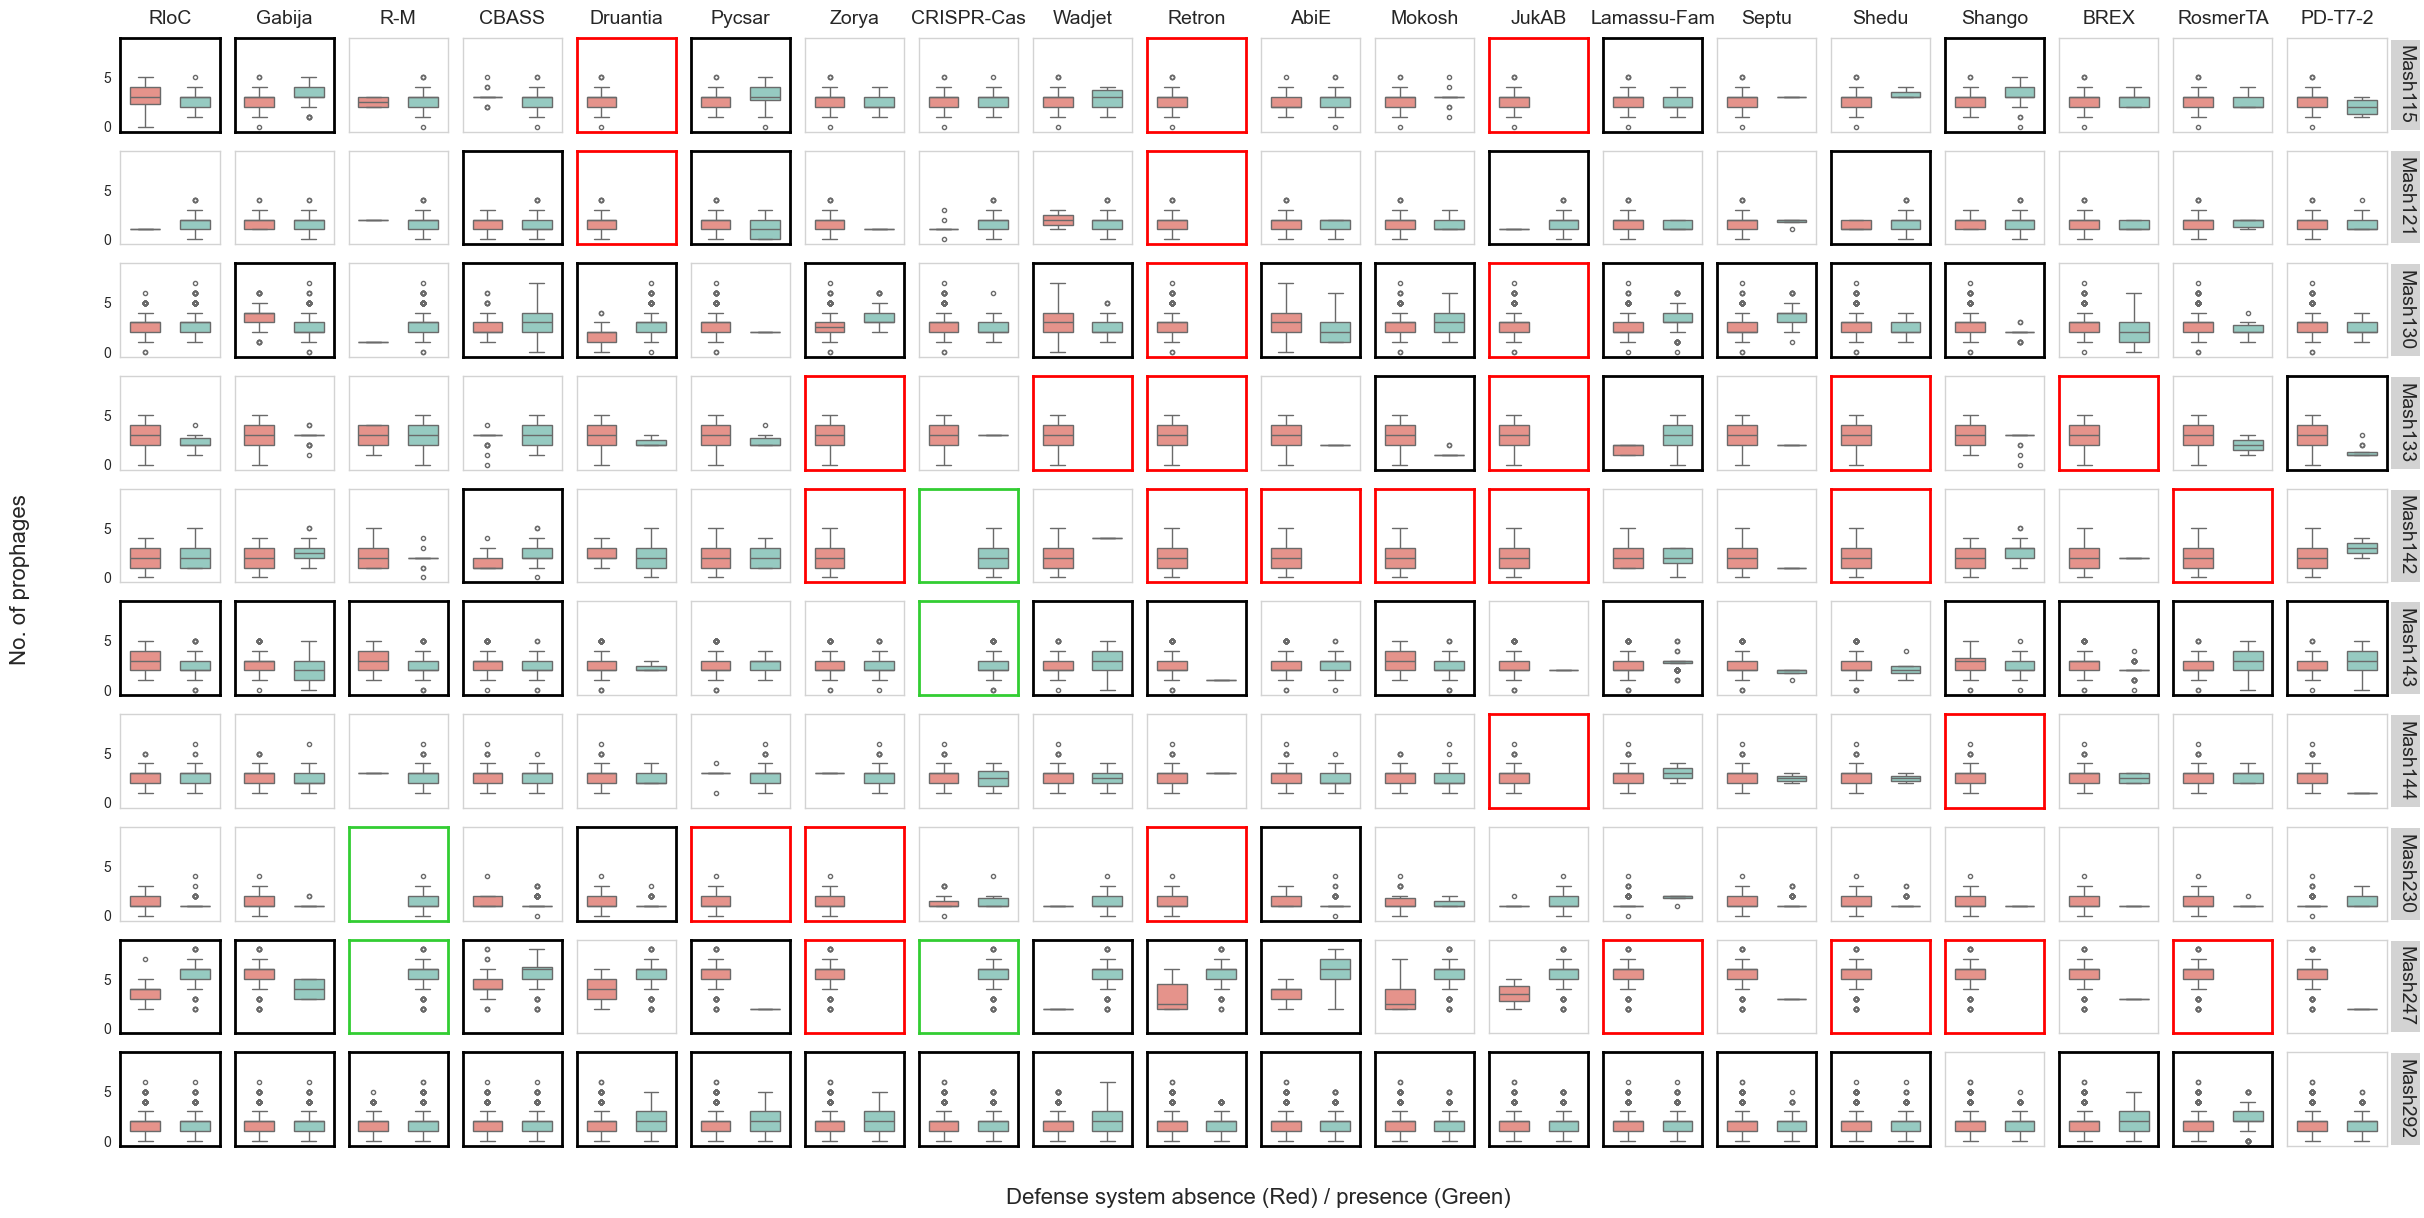

In [1]:
import argparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import sys
import warnings
# 【核心新增】：引入多重检验校正库
from statsmodels.stats.multitest import multipletests

def main():
    sns.set_style("white")
    data = ""
    df_plot = pd.read_csv(data)

    # 强制数据类型，防止 seaborn 绘图顺序错乱
    df_plot['Presence'] = df_plot['Presence'].astype(int)
    df_plot['Prophage_count'] = pd.to_numeric(df_plot['Prophage_count'], errors='coerce')

    top_mash = df_plot['Cluster'].unique()
    top_ds = df_plot['Defense_System'].unique()

    y_max = df_plot['Prophage_count'].max() + 1
    y_min = -0.5

    fig, axes = plt.subplots(nrows=len(top_mash), ncols=len(top_ds),
                             figsize=(max(len(top_ds) * 1.3, 10), max(len(top_mash) * 1.3, 8)),
                             sharey=True)

    if len(top_mash) == 1 and len(top_ds) == 1:
        axes = np.array([[axes]])
    elif len(top_mash) == 1:
        axes = axes.reshape(1, -1)
    elif len(top_ds) == 1:
        axes = axes.reshape(-1, 1)

    palette = {0: '#F4867C', 1: '#8DD3C7'}

    p_value_records = []

    for i, cluster in enumerate(top_mash):
        for j, ds in enumerate(top_ds):
            ax = axes[i, j]

            sub_df = df_plot[(df_plot['Cluster'] == cluster) & (df_plot['Defense_System'] == ds)]

            absence_data = sub_df[sub_df['Presence'] == 0]['Prophage_count']
            presence_data = sub_df[sub_df['Presence'] == 1]['Prophage_count']

            if not sub_df.empty:
                sns.boxplot(data=sub_df, x='Presence', y='Prophage_count', ax=ax,
                            order=[0, 1],
                            hue_order=[0, 1],
                            hue='Presence', palette=palette, legend=False,
                            width=0.6, linewidth=1, fliersize=3)

            # 显式锁定 X 轴范围
            ax.set_xlim(-0.5, 1.5)
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_xticks([])
            if j > 0: ax.tick_params(left=False)

            # 默认边框样式（不显著）
            border_color = 'lightgrey'
            border_width = 1.0

            # 极端情况处理：只有单侧数据，直接画红/绿框，不参与统计检验
            if len(presence_data) == 0 and len(absence_data) > 0:
                border_color = 'red'
                border_width = 2.0
                for spine in ax.spines.values():
                    spine.set_edgecolor(border_color)
                    spine.set_linewidth(border_width)

            elif len(absence_data) == 0 and len(presence_data) > 0:
                border_color = 'limegreen'
                border_width = 2.0
                for spine in ax.spines.values():
                    spine.set_edgecolor(border_color)
                    spine.set_linewidth(border_width)

            # 核心检验情况：两侧都有数据
            elif len(presence_data) > 0 and len(absence_data) > 0:
                try:
                    if presence_data.var() == 0 and absence_data.var() == 0 and presence_data.iloc[0] == absence_data.iloc[0]:
                        pval = 1.0
                    else:
                        stat, pval = mannwhitneyu(absence_data, presence_data, alternative='two-sided')

                    p_value_records.append({
                        'ax': ax,
                        'pval': pval,
                        'cluster': cluster,
                        'ds': ds
                    })

                    for spine in ax.spines.values():
                        spine.set_edgecolor(border_color)
                        spine.set_linewidth(border_width)

                except ValueError:
                    pass

            # 设置行列标题
            if i == 0:
                ax.set_title(ds, fontsize=14, pad=10)
            if j == len(top_ds) - 1:
                ax.text(1.1, 0.5, f"Mash{cluster}", transform=ax.transAxes,
                        ha='left', va='center', rotation=-90, fontsize=14,
                        bbox=dict(boxstyle="square,pad=0.3", fc="lightgrey", ec="none"))


    if p_value_records:
        raw_pvals = [rec['pval'] for rec in p_value_records]

        reject, pvals_corrected, _, _ = multipletests(raw_pvals, alpha=0.05, method='fdr_bh')

        print("\n=== 多重检验校正结果 (FDR-BH) ===")
        for rec, is_significant, qval in zip(p_value_records, reject, pvals_corrected):
            # 如果校正后依然显著，覆盖原本的灰色边框，画上黑色粗边框
            if is_significant:
                for spine in rec['ax'].spines.values():
                    spine.set_edgecolor('black')
                    spine.set_linewidth(2.0)

            # 在终端打印详细数据，供逻辑复核
            print(f"Cluster: Mash{rec['cluster']:<5} | DS: {rec['ds']:<15} | "
                  f"Raw p-val: {rec['pval']:.4e} -> BH q-val: {qval:.4e} | Significant: {is_significant}")
        print("=================================\n")

    plt.ylim(y_min, y_max)

    fig.text(0.5, 0.02, 'Defense system absence (Red) / presence (Green)', ha='center', fontsize=16)
    fig.text(0.02, 0.5, 'No. of prophages', va='center', rotation='vertical', fontsize=16)

    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])

    # 保存图像
    plt.show()

if __name__ == '__main__':
    main()